Device: cuda


100%|██████████| 170M/170M [37:53<00:00, 75.0kB/s]   


Parameters: 11,173,962
No checkpoint found — starting fresh

Training for 200 epochs...

  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
Epoch [ 10/200] Loss: 0.568 | Train Acc: 80.5% | Test Acc: 79.7% | LR: 0.09938 | Best: 79.7%
  → Checkpoint saved: last_checkpoint.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
Epoch [ 20/200] Loss: 0.405 | Train Acc: 86.2% | Test Acc: 74.7% | LR: 0.09755 | Best: 82.8%
  → Checkpoint saved: last_checkpoint.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
  → Checkpoint saved: best_model.pth
Epoch [ 30/200] Loss: 0.357 | Train Acc: 87.9% | Test Acc: 81.1% | LR: 0.09455 | Best:

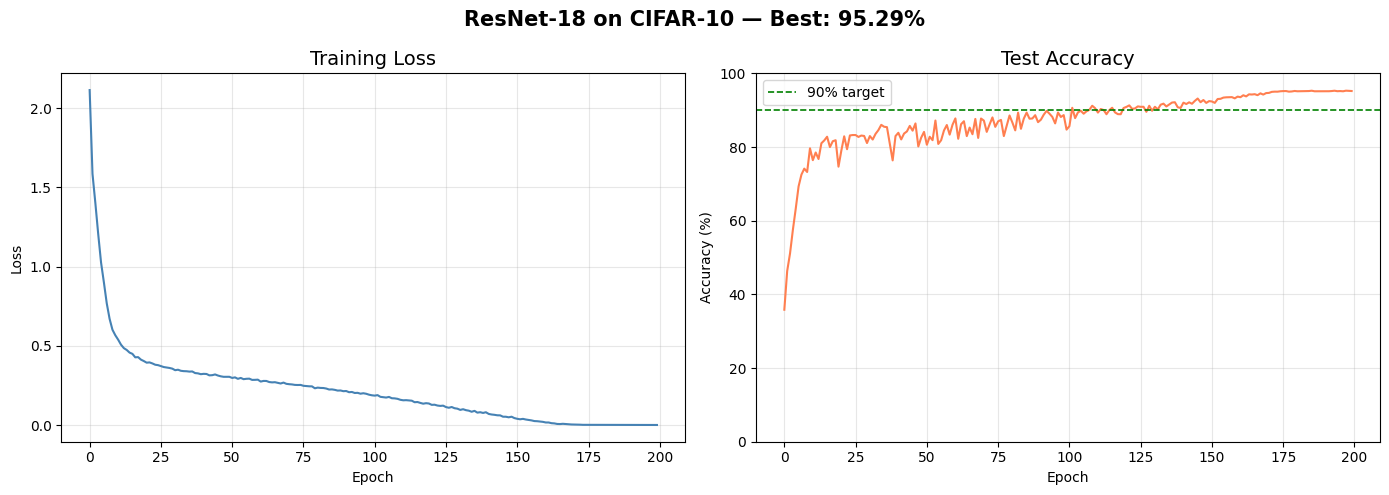


Plot saved as resnet18_cifar10_curves.png


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os

#residual block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = self.relu(out)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


def get_dataloaders(batch_size=128):
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2023, 0.1994, 0.2010)
        )
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2023, 0.1994, 0.2010)
        )
    ])

    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True,
        download=True, transform=train_transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False,
        download=True, transform=test_transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, num_workers=2, pin_memory=True
    )
    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=batch_size,
        shuffle=False, num_workers=2, pin_memory=True
    )

    return train_loader, test_loader


#checkpoint
def save_checkpoint(state, filename):
    torch.save(state, filename)
    print(f'  → Checkpoint saved: {filename}')


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return total_loss / len(loader), 100. * correct / total

def test_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return total_loss / len(loader), 100. * correct / total


def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')

    batch_size = 128
    num_epochs = 200
    learning_rate = 0.1

    best_ckpt  = 'best_model.pth'   
    last_ckpt  = 'last_checkpoint.pth'  

    train_loader, test_loader = get_dataloaders(batch_size)

    model = ResNet18(num_classes=10).to(device)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=0.9,
        weight_decay=5e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs
    )

    train_losses = []
    test_accuracies = []
    best_acc = 0.0
    start_epoch = 0

    if os.path.exists(last_ckpt):
        print(f'\nFound checkpoint — resuming from {last_ckpt}')
        checkpoint = torch.load(last_ckpt, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_acc = checkpoint['best_acc']
        train_losses = checkpoint['train_losses']
        test_accuracies = checkpoint['test_accuracies']
        print(f'Resumed from epoch {start_epoch}, best acc so far: {best_acc:.2f}%\n')
    else:
        print('No checkpoint found — starting fresh\n')

    print(f'Training for {num_epochs} epochs...\n')

    for epoch in range(start_epoch, num_epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device
        )
        test_loss, test_acc = test_epoch(
            model, test_loader, criterion, device
        )
        scheduler.step()

        train_losses.append(train_loss)
        test_accuracies.append(test_acc)


        if test_acc > best_acc:
            best_acc = test_acc
            save_checkpoint({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_acc': best_acc,
                'train_losses': train_losses,
                'test_accuracies': test_accuracies
            }, best_ckpt)

        if (epoch + 1) % 10 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f'Epoch [{epoch+1:>3}/{num_epochs}] '
                  f'Loss: {train_loss:.3f} | '
                  f'Train Acc: {train_acc:.1f}% | '
                  f'Test Acc: {test_acc:.1f}% | '
                  f'LR: {current_lr:.5f} | '
                  f'Best: {best_acc:.1f}%')

            save_checkpoint({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_acc': best_acc,
                'train_losses': train_losses,
                'test_accuracies': test_accuracies
            }, last_ckpt)

    print(f'\nBest Test Accuracy: {best_acc:.2f}%')
    print(f'Final Test Accuracy: {test_accuracies[-1]:.2f}%')

    #plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(train_losses, color='steelblue', linewidth=1.5)
    ax1.set_title('Training Loss', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    ax2.plot(test_accuracies, color='coral', linewidth=1.5)
    ax2.axhline(y=90, color='green', linestyle='--',
                linewidth=1.2, label='90% target')
    ax2.set_title('Test Accuracy', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 100])

    plt.suptitle(f'ResNet-18 on CIFAR-10 — Best: {best_acc:.2f}%',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('resnet18_cifar10_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nPlot saved as resnet18_cifar10_curves.png')


main()